# Posterior Analysis of MHNs

In [1]:
import mhn
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import sys
sys.path.append("../MCMC-sampling-for-MHN")

from analysis.utils import plotting as mcmc_plotting
from analysis.utils import analysis as mcmc_analysis
import plotting

burn_in = 0.2

c:\Users\Arbeit\Documents\Dissertation-MHN-example\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
log_thetas = np.load("../run/results/mcmc.npy", mmap_mode="r")
log_thetas = log_thetas[:, int(log_thetas.shape[1] * 0.2):].reshape(-1, log_thetas.shape[2])
n_events = int(np.sqrt(log_thetas.shape[1]))

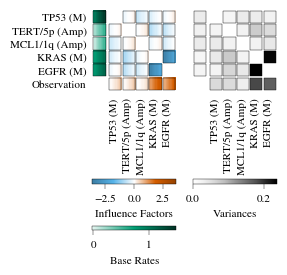

In [3]:
tile_len = 10

quantiles = np.quantile(log_thetas,
                        np.linspace(0.05, 0.95, tile_len),
                        axis=0).T.reshape(n_events + 1, -1)
variances = np.var(log_thetas, axis=0).reshape(n_events + 1, -1)

fig = plt.figure(figsize=(2.8, 2.8))
gs = mpl.gridspec.GridSpec(
    2, 1, height_ratios=[1, 0.3], hspace=0)
theta_gs = mpl.gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs[0])
cbar_gs = mpl.gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs[1], hspace=10)

border_len = 0.1
br_ir_sep = 0.2

ax = np.array([
    fig.add_subplot(theta_gs[0, i]) for i in range(2)])
cbar_ax = np.array([fig.add_subplot(cbar_gs[i // 2, i % 2])
                   for i in range(3)])

max_abs_ir = mcmc_plotting.max_abs_ir(quantiles=quantiles, tile_len=tile_len)
br_min, br_max = mcmc_plotting.min_max_br(quantiles=quantiles, tile_len=tile_len)
max_var = variances.max()

data = pd.read_csv("../data/primary.csv", index_col=0)
event_names = data.columns.tolist()

mcmc_plotting.plot_theta_dist(
    quantiles=quantiles,
    tile_len=tile_len,
    n_events=n_events,
    abs_max_ir=max_abs_ir,
    min_br=br_min,
    max_br=br_max,
    events=event_names,
    ax=ax[0])
mcmc_plotting.plot_theta_var(
    variances=variances,
    n_events=n_events,
    max_var=max_var,
    events=event_names,
    ax=ax[1])

ax[0].set_yticks(np.arange(0.5, n_events + 1 +
                           n_events * border_len, 1 + border_len))
ax[0].set_yticklabels(
    event_names + ["Observation"], )
ax[0].tick_params(length=0, pad=4)

for j in range(2):
    ax[j].set_xticks(
        [0.5]
        + (np.arange(1.5, n_events + 1 + n_events *
                     border_len,
                     1 + border_len) + br_ir_sep).tolist())
    ax[j].set_xticklabels([""] + event_names, rotation=90)
    ax[j].tick_params(length=0, pad=4)

cbars = list()
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=-max_abs_ir, vmax=max_abs_ir), cmap=mcmc_plotting.OI_RdBu),
    cax=cbar_ax[0],
    label="Influence Factors",
    orientation="horizontal",
))
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=0, vmax=max_var), cmap="Greys"),
    cax=cbar_ax[1],
    label="Variances",
    orientation="horizontal",
))
cbars.append(plt.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(
        vmin=br_min, vmax=br_max), cmap=mcmc_plotting.OI_Greens),
    cax=cbar_ax[2],
    label="Base Rates",
    orientation="horizontal",
))

for cbar in cbars:
    cbar.outline.set_linewidth(0.3)
    cbar.ax.tick_params(width=0.3)

fig.tight_layout()
fig.savefig("results/posterior_param_dist.pdf")

In [4]:
n_bins = 100
np.random.seed(0)
positions = mcmc_analysis.event_positions(
    log_thetas=log_thetas, n_bins=n_bins, n_samples=100)

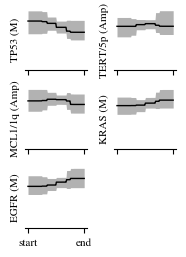

In [10]:
n_cols = 2
n_rows = (n_events - 1) // n_cols + 1

fig, ax = plt.subplots(
    n_rows, n_cols,
    figsize=(1.9, 2.6),
    sharex=True,
            )

for i in range(n_events):

    q_5, q_50, q_95 = np.percentile(
        positions[:, i, :], [5, 50, 95], axis=0)
    ax[i // n_cols, i % n_cols].plot(
        q_50, lw=1, color="black")
    ax[i // n_cols, i % n_cols].fill_between(
        np.arange(n_bins), q_5, q_95, alpha=0.3, color="black", lw=0
    )
    ax[i // n_cols, i % n_cols].set_ylabel(f"{event_names[i]}", fontsize=8)
    for spine in ["top", "right", "left"]:
        ax[i // n_cols, i % n_cols].spines[spine].set_visible(False)
    _ = ax[i // n_cols, i % n_cols].set_yticks([])
    _ = ax[i // n_cols, i % n_cols].set_xticks([0, n_bins-1])
    _ = ax[i // n_cols, i % n_cols].set_xticklabels(["start", "end"])
    ax[i // n_cols, i % n_cols].set_ylim(0, None, auto=True)

if n_events % n_cols != 0:
    for i in range(n_cols - (n_events % n_cols)):
        ax[-1, -1 - i].set_visible(False)

fig.tight_layout()
fig.subplots_adjust(top=0.96, hspace=0.3
                    )
fig.savefig("results/posterior_positions.pdf", dpi=600)

In [6]:
risks = mcmc_analysis.event_risks(
    log_thetas,
    data=data,
    n_samples=100,
    trajectory_num=1000,
)

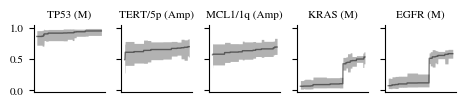

In [9]:
fig, ax = plt.subplots(ncols=n_events, figsize=(4.7, 1.1), sharey=True)

for i in range(n_events):

    a = ax[i]

    data_filtered = data.reset_index(drop=True)[
        data.reset_index(drop=True).iloc[:, i] == 0]
    sorting = None

    risk = risks[data_filtered.index, :, i]
    sorting = np.argsort(np.median(risk, axis=1))
    a.plot(np.median(risk, axis=1)[sorting],
           lw=1, alpha=0.5, color="black")
    a.fill_between(
        np.arange(risk.shape[0]),
        np.percentile(risk, 5, axis=1)[sorting],
        np.percentile(risk, 95, axis=1)[sorting],
        alpha=0.3, color="black", lw=0)

    for side in ["top", "right"]:
        a.spines[side].set_visible(False)
    a.set_xticks([])
    a.set_title(f"{data.columns[i]}", fontsize=8)
fig.tight_layout()
fig.savefig("results/posterior_mutation_risks.pdf", dpi=600)
